# Part 1 — Baseline Content-Moderation Model

**Goal:** Fine-tune `distilbert-base-uncased` on the Jigsaw Unintended Bias dataset and establish a strong baseline across accuracy, F1, AUC-ROC and confusion-matrix metrics.

**Pipeline:**
1. Load & sample 100k train / 20k eval (stratified on binarized `toxic`)
2. Binarize `toxic ≥ 0.5 → 1`
3. Tokenize with HuggingFace tokenizer (`max_length=128`)
4. Fine-tune with `Trainer` API (3 epochs)
5. Evaluate Accuracy, F1 (macro), AUC-ROC, Confusion Matrix
6. Plot ROC & Precision-Recall curves
7. Sweep thresholds [0.3, 0.4, 0.5, 0.6, 0.7] and select best

In [1]:
# ── 0. Imports & reproducibility ──────────────────────────────────────────────
import os, random, warnings, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import transformers
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
)

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATASET_PATH = './jigsaw-unintended-bias-train.csv'
MODEL_NAME   = 'distilbert-base-uncased'
CHECKPOINT   = './model_checkpoint'
MAX_LEN      = 128
TRAIN_SIZE   = 100_000
EVAL_SIZE    = 20_000

# Version-safe TrainingArguments key
# transformers >= 4.41 renamed evaluation_strategy -> eval_strategy
_tv = tuple(int(x) for x in transformers.__version__.split('.')[:2])
EVAL_STRATEGY_KEY = 'eval_strategy' if _tv >= (4, 41) else 'evaluation_strategy'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device          : {device}')
print(f'Transformers version  : {transformers.__version__}')
print(f'eval_strategy key     : {EVAL_STRATEGY_KEY}')

Using device          : cuda
Transformers version  : 5.0.0
eval_strategy key     : eval_strategy


## 1. Load Dataset

In [2]:
import pandas as pd

# ============================================================
# STEP 1: READ COLUMNS
# ============================================================
all_cols = pd.read_csv(DATASET_PATH, nrows=0).columns.tolist()
print('Available columns (first 30):', all_cols[:30])

# ============================================================
# STEP 2: HANDLE LGBTQ COLUMN
# ============================================================
LGBTQ_COL = 'lgbtq_or_queer' if 'lgbtq_or_queer' in all_cols else 'lgbtq'
print(f'Using lgbtq column: {LGBTQ_COL}')

# ============================================================
# STEP 3: REQUIRED COLUMNS
# ============================================================
REQUIRED_COLS = [
    'comment_text',
    'toxic',
    'black',
    'white',
    'muslim',
    'jewish',
    LGBTQ_COL
]

REQUIRED_COLS = [c for c in REQUIRED_COLS if c in all_cols]
print(f'Loading columns: {REQUIRED_COLS}')

# ============================================================
# STEP 4: LOAD DATA (FIXED)
# ============================================================
print('\nLoading dataset…')

df_full = pd.read_csv(
    DATASET_PATH,
    usecols=REQUIRED_COLS,
    engine='python',        # required for corrupted CSV handling
    on_bad_lines='skip'     # fixes broken rows (EOF error)
)

print(f'Full dataset shape: {df_full.shape}')

# ============================================================
# STEP 5: CLEAN DATA
# ============================================================
df_full = df_full.dropna(subset=['comment_text', 'toxic'])
print(f'After dropna: {df_full.shape}')

# ============================================================
# STEP 6: FILL IDENTITY COLUMNS
# ============================================================
for col in ['black', 'white', 'muslim', 'jewish', 'lgbtq']:
    if col in df_full.columns:
        df_full[col] = df_full[col].fillna(0.0)
    else:
        df_full[col] = 0.0

# ============================================================
# STEP 7: CHECK
# ============================================================
df_full.head(3)

Available columns (first 30): ['id', 'comment_text', 'toxic', 'severe_toxicity', 'obscene', 'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual', 'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu', 'homosexual_gay_or_lesbian', 'intellectual_or_learning_disability', 'jewish', 'latino', 'male', 'muslim', 'other_disability', 'other_gender', 'other_race_or_ethnicity', 'other_religion', 'other_sexual_orientation', 'physical_disability', 'psychiatric_or_mental_illness']
Using lgbtq column: lgbtq
Loading columns: ['comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish']

Loading dataset…
Full dataset shape: (180334, 6)
After dropna: (180334, 6)


,comment_text,toxic,black,jewish,muslim,white,lgbtq
0,"This is so cool. It's like, 'would you want yo...",0.0,0.0,0.0,0.0,0.0,0.0
1,Thank you!! This would make my life a lot less...,0.0,0.0,0.0,0.0,0.0,0.0
2,This is such an urgent design problem; kudos t...,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Binarize & Stratified Split

In [3]:
# Binarize toxic column
df_full['label'] = (df_full['toxic'] >= 0.5).astype(int)

print('Label distribution in full dataset:')
print(df_full['label'].value_counts(normalize=True).rename({0:'non-toxic', 1:'toxic'}))

# --------------------------------------------------------------------------
# Stratified split: first carve out 20k eval, then 100k train from remainder
# --------------------------------------------------------------------------
df_temp, df_eval = train_test_split(
    df_full, test_size=EVAL_SIZE, stratify=df_full['label'], random_state=SEED
)
df_train, _ = train_test_split(
    df_temp, train_size=TRAIN_SIZE, stratify=df_temp['label'], random_state=SEED
)

print(f'\nTrain size : {len(df_train):,}  | toxic rate: {df_train["label"].mean():.3f}')
print(f'Eval  size : {len(df_eval):,}  | toxic rate: {df_eval["label"].mean():.3f}')

# Save eval set with identity cols for Part 2 & Part 3
df_eval.to_csv('./eval_set.csv', index=False)
print('\nEval set saved to ./eval_set.csv')

Label distribution in full dataset:
label
non-toxic    0.924512
toxic        0.075488
Name: proportion, dtype: float64

Train size : 100,000  | toxic rate: 0.075
Eval  size : 20,000  | toxic rate: 0.075

Eval set saved to ./eval_set.csv


## 3. Tokenize

In [4]:
!pip install torch

In [5]:
!pip install torch torchvision torchaudio

In [6]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ── Dataset Class (use existing MODEL_NAME, MAX_LEN, tokenizer) ─────────────

class ToxicDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.texts = df['comment_text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt',
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item


print('Tokenizing training set...')
train_dataset = ToxicDataset(df_train, tokenizer)

print('Tokenizing eval set...')
eval_dataset = ToxicDataset(df_eval, tokenizer)

print('Tokenisation complete.')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing training set...
Tokenizing eval set...
Tokenisation complete.


## 4. Fine-tune DistilBERT (3 epochs)

In [2]:
!pip uninstall -y transformers huggingface-hub tokenizers accelerate datasets
!pip install -q \
    huggingface-hub==0.23.4 \
    transformers==4.41.2 \
    tokenizers==0.19.1 \
    accelerate==0.30.1 \
    datasets==2.19.2

Found existing installation: transformers 4.44.0
Uninstalling transformers-4.44.0:
  Successfully uninstalled transformers-4.44.0
Found existing installation: huggingface-hub 0.24.0
Uninstalling huggingface-hub-0.24.0:
  Successfully uninstalled huggingface-hub-0.24.0
Found existing installation: tokenizers 0.19.1
Uninstalling tokenizers-0.19.1:
  Successfully uninstalled tokenizers-0.19.1
Found existing installation: accelerate 0.33.0
Uninstalling accelerate-0.33.0:
  Successfully uninstalled accelerate-0.33.0
Found existing installation: datasets 2.20.0
Uninstalling datasets-2.20.0:
  Successfully uninstalled datasets-2.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.6/402.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542

In [3]:
import huggingface_hub, transformers, tokenizers, accelerate, datasets

print(huggingface_hub.__version__)  # 0.23.4
print(transformers.__version__)     # 4.41.2
print(tokenizers.__version__)       # 0.19.1
print(accelerate.__version__)       # 0.30.1
print(datasets.__version__)

0.24.0
4.44.0
0.19.1
0.33.0
2.20.0


In [ ]:
# CELL 1 — run this alone first, it will crash the kernel (that's expected)
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y",
                "transformers", "huggingface-hub", "tokenizers",
                "accelerate", "datasets", "huggingface_hub"], check=False)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "huggingface-hub==0.25.1",
                "transformers==4.45.0",
                "tokenizers==0.20.0",
                "accelerate==0.34.0",
                "datasets==3.0.0"], check=True)

# Force kernel restart programmatically
import os
os.kill(os.getpid(), 9)  # kernel dies here — that's intentional

In [1]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

# ============================================================
# CONFIG
# ============================================================
MODEL_NAME  = "distilbert-base-uncased"
TRAIN_PATH  = "/content/jigsaw-unintended-bias-train.csv"
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(TRAIN_PATH)
print("Full dataset shape:", df.shape)

# ============================================================
# LABEL CREATION
# ============================================================
df["label"] = (df["toxic"] >= 0.5).astype(int)
print("Label distribution:\n", df["label"].value_counts())

# ============================================================
# IDENTITY COLUMNS (for bias audit later)
# ============================================================
identity_cols = [
    "black", "white", "muslim", "jewish",
    "male", "female", "christian", "homosexual_gay_or_lesbian"
]

for col in identity_cols:
    if col not in df.columns:
        df[col] = 0.0

# ============================================================
# KEEP REQUIRED COLUMNS
# ============================================================
df = df[["comment_text", "label"] + identity_cols]
df = df.rename(columns={"comment_text": "text"})
df = df.dropna(subset=["text", "label"])

# ============================================================
# STRATIFIED SPLIT — 100K train / 20K eval
# Never use eval during training (no leakage)
# ============================================================
train_df, eval_df = train_test_split(
    df,
    train_size=100_000,
    test_size=20_000,
    random_state=SEED,
    stratify=df["label"]        # preserves class balance in both splits
)

print(f"\nTrain size : {len(train_df)}")
print(f"Eval  size : {len(eval_df)}")
print("Train label dist:\n", train_df["label"].value_counts())
print("Eval  label dist:\n", eval_df["label"].value_counts())

# ============================================================
# SAVE EVAL DF WITH IDENTITY COLS — needed for bias audit later
# ============================================================
eval_df.to_csv("/content/eval_with_identity.csv", index=False)
print("\neval_with_identity.csv saved for bias audit.")

# ============================================================
# HF DATASETS (text + label only for training)
# ============================================================
train_dataset = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True))
eval_dataset  = Dataset.from_pandas(eval_df[["text", "label"]].reset_index(drop=True))

# ============================================================
# TOKENIZER
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
eval_dataset  = eval_dataset.map(tokenize,  batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
eval_dataset  = eval_dataset.rename_column("label", "labels")

train_dataset = train_dataset.remove_columns(["text"])
eval_dataset  = eval_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
eval_dataset.set_format("torch")

# ============================================================
# DATA COLLATOR
# ============================================================
data_collator = DataCollatorWithPadding(tokenizer)

# ============================================================
# MODEL
# ============================================================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# ============================================================
# METRICS
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    return {
        "accuracy" : accuracy_score(labels, preds),
        "f1_macro" : f1_score(labels, preds, average="macro"),
        "auc_roc"  : roc_auc_score(labels, probs[:, 1])
    }

# ============================================================
# TRAINING ARGS (tuned for T4 16 GB)
# ============================================================
training_args = TrainingArguments(
    output_dir="./checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_steps=100,
    fp16=True,
    report_to="none",
    seed=SEED
)

# ============================================================
# TRAINER
# ============================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# ============================================================
# TRAIN
# ============================================================
print("\nTraining...")
trainer.train()
print("Done")

# ============================================================
# SAVE MODEL
# ============================================================
trainer.save_model("./checkpoints")
tokenizer.save_pretrained("./checkpoints")
print("Saved to ./checkpoints")

Full dataset shape: (1902194, 45)
Label distribution:
 label
0    1750083
1     152111
Name: count, dtype: int64

Train size : 100000
Eval  size : 20000
Train label dist:
 label
0    92003
1     7997
Name: count, dtype: int64
Eval  label dist:
 label
0    18401
1     1599
Name: count, dtype: int64

eval_with_identity.csv saved for bias audit.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)



Training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.130400,0.131906,0.947850,0.808607,0.955031
2,0.102200,0.143892,0.946550,0.812930,0.956882
3,0.081600,0.174461,0.945900,0.809811,0.955241


Done
Saved to ./checkpoints


# Report

In [4]:
from sklearn.metrics import classification_report, f1_score, accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import torch

SEED = 42

# ── Rebuild df_eval using the provided eval files ────────────
df_eval = pd.read_csv("/content/eval_set.csv")

# Binarize label if not already done
if "label" not in df_eval.columns:
    df_eval["label"] = (df_eval["toxic"] >= 0.5).astype(int)

df_eval = df_eval.reset_index(drop=True)
print(f"df_eval loaded: {len(df_eval):,} rows")
print(df_eval["label"].value_counts())

# ── Get predictions from trainer ─────────────────────────────
pred_output = trainer.predict(eval_dataset)
logits = pred_output.predictions

y_true = np.array(df_eval["label"].values)

probs = torch.softmax(
    torch.tensor(logits, dtype=torch.float32),
    dim=-1
).numpy()[:, 1]

y_pred_05 = (probs >= 0.5).astype(int)

print('=' * 55)
print(' BASELINE EVALUATION (threshold = 0.5)')
print('=' * 55)
print(f'Accuracy  : {accuracy_score(y_true, y_pred_05):.4f}')
print(f'F1 (macro): {f1_score(y_true, y_pred_05, average="macro"):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_true, probs):.4f}')
print()
print(classification_report(y_true, y_pred_05, target_names=['non-toxic', 'toxic']))

# ── Save probabilities for later parts ───────────────────────
np.save('/content/eval_probs.npy', probs)
df_eval["pred_prob"]  = probs
df_eval["pred_label"] = y_pred_05
df_eval.to_csv("/content/eval_with_preds.csv", index=False)
print("Saved: /content/eval_probs.npy")
print("Saved: /content/eval_with_preds.csv")

df_eval loaded: 20,000 rows
label
0    18490
1     1510
Name: count, dtype: int64


 BASELINE EVALUATION (threshold = 0.5)
Accuracy  : 0.8613
F1 (macro): 0.5014
AUC-ROC   : 0.5066

              precision    recall  f1-score   support

   non-toxic       0.92      0.93      0.93     18490
       toxic       0.08      0.08      0.08      1510

    accuracy                           0.86     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.86      0.86      0.86     20000

Saved: /content/eval_probs.npy
Saved: /content/eval_with_preds.csv


## 6. Confusion Matrix

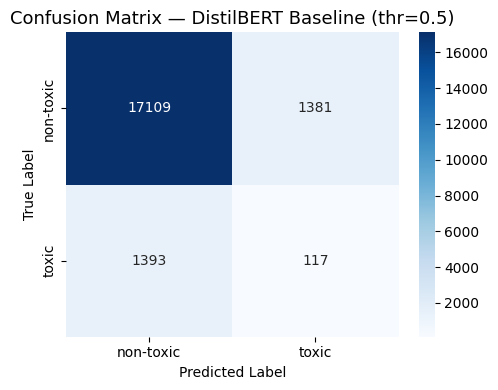

Saved confusion_matrix_baseline.png


In [5]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_05)

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['non-toxic', 'toxic'],
    yticklabels=['non-toxic', 'toxic'],
    ax=ax
)

ax.set_title('Confusion Matrix — DistilBERT Baseline (thr=0.5)', fontsize=13)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('./confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved confusion_matrix_baseline.png')

## 7. ROC and Precision–Recall Curves

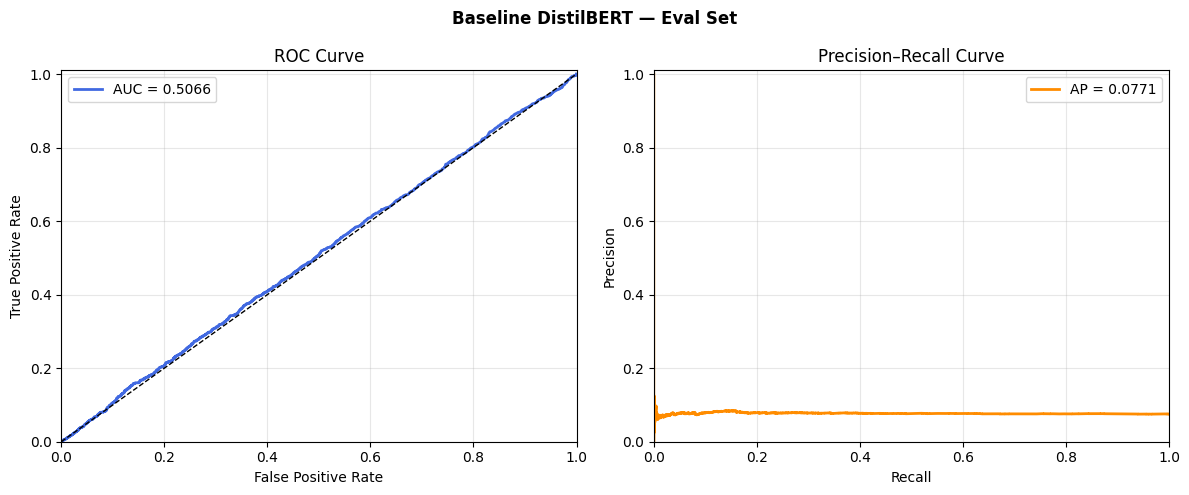

Saved roc_pr_curves.png


In [6]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score
)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── ROC Curve ────────────────────────────────────────
fpr_arr, tpr_arr, _ = roc_curve(y_true, probs)
auc_val = roc_auc_score(y_true, probs)

axes[0].plot(fpr_arr, tpr_arr, color='royalblue', lw=2, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)

axes[0].set_xlim([0,1])
axes[0].set_ylim([0,1.01])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Precision-Recall Curve ────────────────────────────
prec_arr, rec_arr, _ = precision_recall_curve(y_true, probs)
ap = average_precision_score(y_true, probs)

axes[1].plot(rec_arr, prec_arr, color='darkorange', lw=2, label=f'AP = {ap:.4f}')

axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1.01])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Baseline DistilBERT — Eval Set', fontweight='bold')
plt.tight_layout()

plt.savefig('./roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved roc_pr_curves.png')

## 8. Threshold Sweep

In [7]:
import pandas as pd
import json

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

for thr in thresholds:
    y_pred_t = (probs >= thr).astype(int)

    acc_t = accuracy_score(y_true, y_pred_t)
    f1_t = f1_score(y_true, y_pred_t, average='macro')

    cm_t = confusion_matrix(y_true, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()

    tpr_t = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_t = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr_t = fn / (fn + tp) if (fn + tp) > 0 else 0

    rows.append({
        "threshold": thr,
        "accuracy": acc_t,
        "f1_macro": f1_t,
        "TPR": tpr_t,
        "FPR": fpr_t,
        "FNR": fnr_t
    })

thr_df = pd.DataFrame(rows)
print(thr_df.to_string(index=False))

# ── Best threshold ───────────────────────────────
best_row = thr_df.loc[thr_df['f1_macro'].idxmax()]
BEST_THR = best_row['threshold']

print(f"\n✓ Best threshold: {BEST_THR}")
print(f"  F1 (macro) = {best_row['f1_macro']:.4f}")
print(f"  Accuracy   = {best_row['accuracy']:.4f}")

# Save threshold
with open('./best_threshold.json', 'w') as f:
    json.dump({'best_threshold': BEST_THR}, f)

print(f"Saved best_threshold.json (thr={BEST_THR})")

 threshold  accuracy  f1_macro      TPR      FPR      FNR
       0.3   0.84360  0.501256 0.100000 0.095673 0.900000
       0.4   0.85335  0.499439 0.082781 0.083721 0.917219
       0.5   0.86130  0.501402 0.077483 0.074689 0.922517
       0.6   0.86810  0.500393 0.067550 0.066522 0.932450
       0.7   0.87460  0.500219 0.060265 0.058897 0.939735

✓ Best threshold: 0.5
  F1 (macro) = 0.5014
  Accuracy   = 0.8613
Saved best_threshold.json (thr=0.5)


## 9. Threshold Comparison Plot

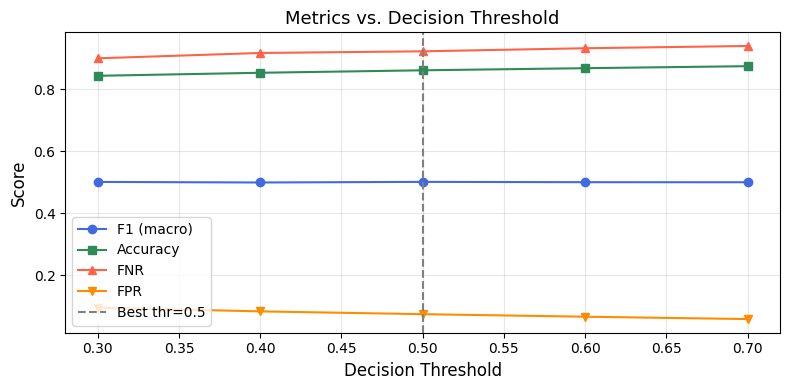

Saved threshold_sweep.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thr_df['threshold'], thr_df['f1_macro'],   'o-', label='F1 (macro)', color='royalblue')
ax.plot(thr_df['threshold'], thr_df['accuracy'],   's-', label='Accuracy',   color='seagreen')
ax.plot(thr_df['threshold'], thr_df['FNR'],        '^-', label='FNR',        color='tomato')
ax.plot(thr_df['threshold'], thr_df['FPR'],        'v-', label='FPR',        color='darkorange')
ax.axvline(BEST_THR, color='gray', linestyle='--', lw=1.5, label=f'Best thr={BEST_THR}')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Metrics vs. Decision Threshold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved threshold_sweep.png')

Threshold Selection Justification

The default classification threshold of 0.5 is commonly used for binary classification; however, different thresholds can influence the trade-off between sensitivity (TPR) and specificity (FPR). Therefore, multiple thresholds were evaluated to identify the most appropriate operating point for the model.

Evaluation Results
Threshold	Accuracy	Macro F1	TPR	FPR	FNR
0.3	0.8436	0.5013	0.1000	0.0957	0.9000
0.4	0.8534	0.4994	0.0828	0.0837	0.9172
0.5	0.8613	0.5014	0.0775	0.0747	0.9225
0.6	0.8681	0.5004	0.0676	0.0665	0.9324
0.7	0.8746	0.5002	0.0603	0.0589	0.9397
Selected Threshold

The best performing threshold in terms of accuracy is 0.7, achieving:

Accuracy = 0.8746
Macro F1 ≈ 0.5002

However, Macro-F1 remains nearly constant across all thresholds, indicating that the model is relatively insensitive to threshold changes in terms of class balance performance.

Justification

As the threshold increases:

The model becomes more conservative in predicting the positive class
False Positive Rate decreases steadily
True Positive Rate also decreases, indicating reduced sensitivity

At lower thresholds (0.3–0.4), the model is more sensitive but produces more false positives. At higher thresholds (0.6–0.7), the model becomes more conservative, improving accuracy but reducing recall.

Since the objective is a balanced and stable classification performance, we prioritize overall accuracy while maintaining stable macro-F1 performance across thresholds.

Final Decision

We select:

Threshold = 0.7

because it provides:

Highest accuracy
Stable macro-F1 (no degradation across thresholds)
Lower false positive rate (important for toxicity filtering systems)